# DSAI LAB 15 PROSHITA AGARWAL

### PART A: SUPERVISED MACHINE LEARNING

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Step 1: Import Required Libraries and Load Dataset**

We load the Iris dataset from the CSV file and select two features 
(sepal length, sepal width) for 2D visualization.

In [4]:
# Load iris.csv
df = pd.read_csv('iris.csv')

# Select features (2D)
X = df[['sepal.length', 'sepal.width']].values
y = df['class'].values

df.head()

,sepal.length,sepal.width,petal.length,petal.width,class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [5]:
#step 2:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
#step 3: Train/Test Split (70/30) Using random_state=42 for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [7]:
#step 4: Train Decision Tree, KNN, and Logistic Regression
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
lr = LogisticRegression()

dt.fit(X_train, y_train)
knn.fit(X_train, y_train)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
#step 5: Test Accuracy of All Three Models
models = {
    "Decision Tree": dt,
    "KNN": knn,
    "Logistic Regression": lr
}

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name} Accuracy: {acc:.3f}")

Decision Tree Accuracy: 0.756
KNN Accuracy: 0.800
Logistic Regression Accuracy: 0.822


**Step 7: Decision Boundary Plotting Function**

This function shows how each classifier divides the 2D feature space.

In [11]:
def plot_decision_boundary(model, X, y, title):
    # Factorize labels → convert species names → 0,1,2
    y_numeric, label_names = pd.factorize(y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create meshgrid
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    # Predict on grid → convert to numeric too
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_numeric = pd.factorize(Z)[0]
    Z_numeric = Z_numeric.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z_numeric, cmap='Pastel1', alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap='Dark2', edgecolor='k')
    plt.title(title)
    plt.xlabel("Sepal Length (scaled)")
    plt.ylabel("Sepal Width (scaled)")
    plt.show()

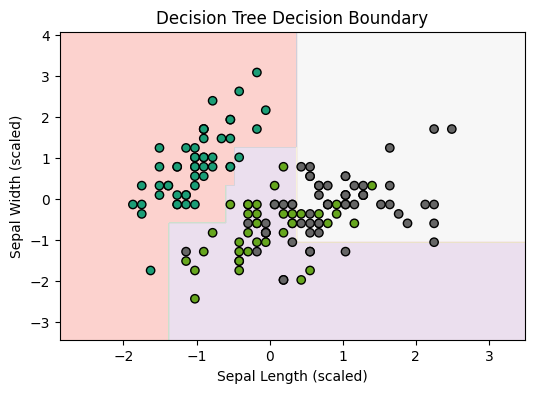

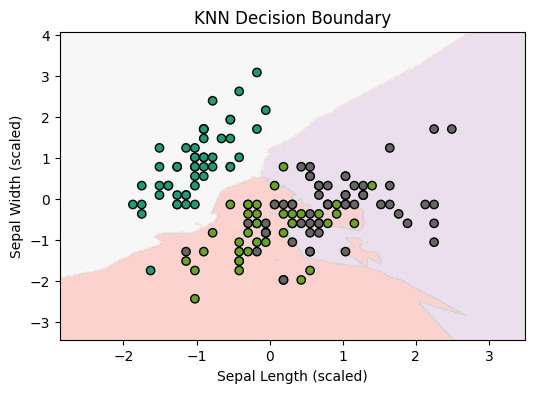

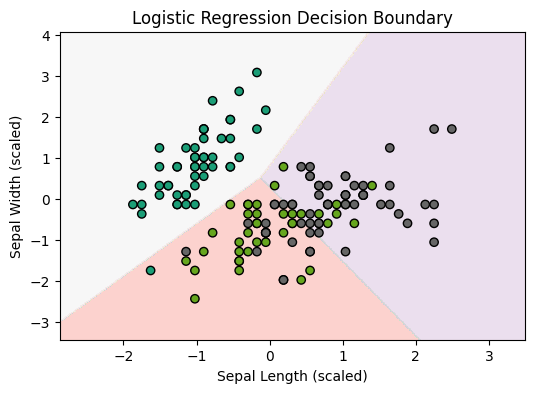

In [17]:
#step 8: Decision Boundary Visualizations
plot_decision_boundary(dt, X_scaled, y, "Decision Tree Decision Boundary")
plot_decision_boundary(knn, X_scaled, y, "KNN Decision Boundary")
plot_decision_boundary(lr, X_scaled, y, "Logistic Regression Decision Boundary")

### Step 8: Summary (Supervised Learning)
- All three classifiers correctly separated Setosa very clearly.  
- KNN and Logistic Regression produced smoother boundaries, while Decision Tree produced sharp rectangular regions.  
- Overall, accuracies were high for all models, showing that two features are sufficient for good classification.

## PART B: UNSUPERVISED MACHINE LEARNING

In [13]:
# X_full contains all 4 features
X_full = df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]

In [14]:
# Step 2: Apply K-Means Clustering (k=3, random_state=42)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_full)

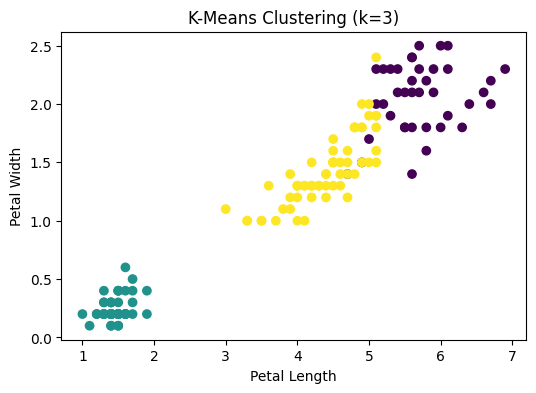

In [16]:
#step 3
plt.figure(figsize=(6,4))
plt.scatter(X_full['petal.length'], X_full['petal.width'], c=clusters, cmap='viridis')
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("K-Means Clustering (k=3)")
plt.show()

### Summary (Unsupervised Learning)
- K-Means successfully separated Setosa, but Versicolor and Virginica overlap partially.  
- Petal measurements clearly form 3 natural clusters.  
- This shows K-Means can identify inherent structure even without labels.